In [1]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Import GPT-2 model and extract its position embedding matrix

In [2]:
from transformers import GPT2Model

# get the Word Position Embeddings matrix
gpt2 = GPT2Model.from_pretrained('gpt2')
positions =gpt2.wpe.weight.detach().squeeze()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

# Exercise 1: Histogram of embeddings cosine similarities

In [3]:
# copied from "embed_positionEmbeddings.ipynb"

# cosine similarities for "time series" (token index)
Pnorm1 = positions / np.linalg.norm(positions,axis=1,keepdims=True)
cossim_tokens = Pnorm1 @ Pnorm1.T

# cosine similarities across embedding dimensions
Pnorm0 = positions / np.linalg.norm(positions,axis=0,keepdims=True)
cossim_embeds = Pnorm0.T @ Pnorm0

/tmp/ipykernel_2499/1383727513.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  Pnorm1 = positions / np.linalg.norm(positions,axis=1,keepdims=True)
/tmp/ipykernel_2499/1383727513.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  Pnorm0 = positions / np.linalg.norm(positions,axis=0,keepdims=True)


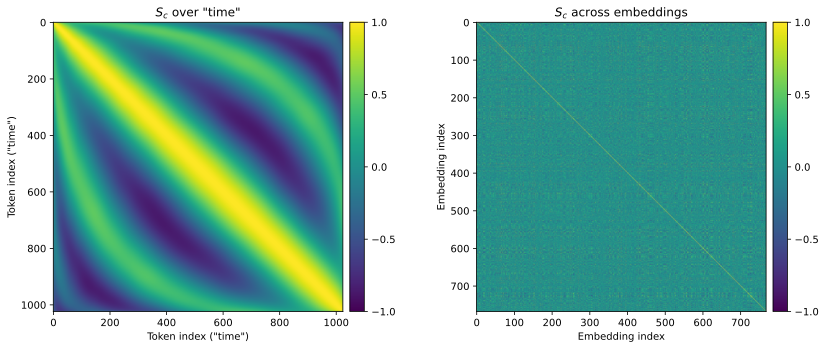

In [4]:
# draw the images (also copied from previous code file)
fig,axs = plt.subplots(1,2,figsize=(12,5))

h = axs[0].imshow(cossim_tokens,vmin=-1,vmax=1)
axs[0].set(xlabel='Token index ("time")',ylabel='Token index ("time")',title='$S_c$ over "time"')
ch = fig.colorbar(h,ax=axs[0],pad=.02,fraction=.046)
ch.ax.tick_params(labelsize=10)
ch.ax.set_yticks(np.arange(-1,1.1,.5))

h = axs[1].imshow(cossim_embeds,vmin=-1,vmax=1)
axs[1].set(xlabel='Embedding index',ylabel='Embedding index',title='$S_c$ across embeddings')
ch = fig.colorbar(h,ax=axs[1],pad=.02,fraction=.046)
ch.ax.tick_params(labelsize=10)
ch.ax.set_yticks(np.arange(-1,1.1,.5))

plt.tight_layout()
plt.show()

In [5]:
# small demo about triu:
A = np.random.randint(0,9,(4,4))
print(A)
print('')
A[np.nonzero(np.triu(A,1))]

[[8 1 2 1]
 [0 2 7 8]
 [4 6 4 3]
 [4 0 4 4]]



array([1, 2, 1, 7, 8, 3])

In [13]:
# get the unique cosine similarity values from the upper-triangle
unique_cs_embeds = cossim_embeds[np.nonzero(np.triu(cossim_embeds, 1))] # avoid the trivial diagonal
unique_cs_tokens = cossim_tokens[np.nonzero(np.triu(cossim_tokens, 1))]

# get their distributions
embed_hy,embed_hx = np.histogram(unique_cs_embeds, 100)
token_hy,token_hx = np.histogram(unique_cs_tokens, 100)


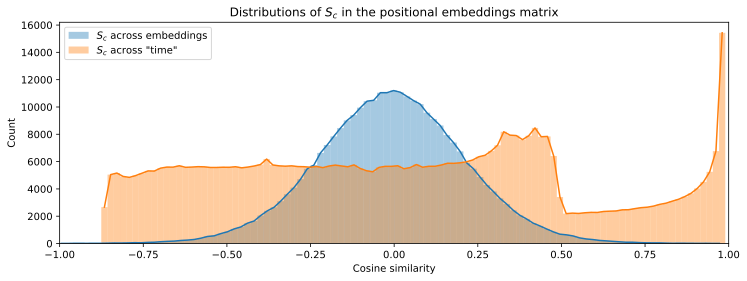

In [16]:

# visualize!
plt.figure(figsize=(12,4))
plt.bar(embed_hx[:-1],embed_hy,width=np.diff(embed_hx[:2]),alpha=.4,label='$S_c$ across embeddings')
plt.bar(token_hx[:-1], token_hy, width=np.diff(token_hx[:2]), alpha=.4, label='$S_c$ across "time"')
plt.plot(embed_hx[:-1],embed_hy)
plt.plot(token_hx[:-1],token_hy)

plt.legend()
plt.gca().set(xlim=[-1,1],xlabel='Cosine similarity',ylabel='Count',title='Distributions of $S_c$ in the positional embeddings matrix')
plt.show()

# Exercise 2: Create a shuffled cosine similarity distribution

In [17]:
#  random shuffling of embeddings values
randomEmbeds = positions.flatten()

np.random.shuffle(randomEmbeds)
randomEmbeds = randomEmbeds.reshape(positions.shape)

/tmp/ipykernel_2499/3184925382.py:4: UserWarning: you are shuffling a 'Tensor' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  np.random.shuffle(randomEmbeds)


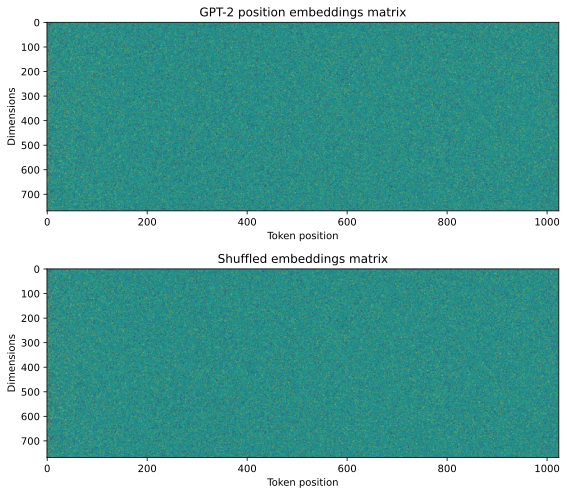

In [21]:
_,axs = plt.subplots(2,1,figsize=(8,7))

axs[0].imshow(positions.T,aspect='auto',vmin=-.1,vmax=.1)
axs[0].set(xlabel='Token position',ylabel='Dimensions',title='GPT-2 position embeddings matrix')

axs[1].imshow(randomEmbeds.T,aspect='auto',vmin=-.1,vmax=.1)
axs[1].set(xlabel='Token position',ylabel='Dimensions',title='Shuffled embeddings matrix')


plt.tight_layout()
plt.show()

In [22]:
# calculate cosine similarity
Rnorm0 = randomEmbeds / np.linalg.norm(randomEmbeds, axis=0, keepdims=True)
cossim_random = Rnorm0.T @ Rnorm0

/tmp/ipykernel_2499/1926148314.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  Rnorm0 = randomEmbeds / np.linalg.norm(randomEmbeds, axis=0, keepdims=True)


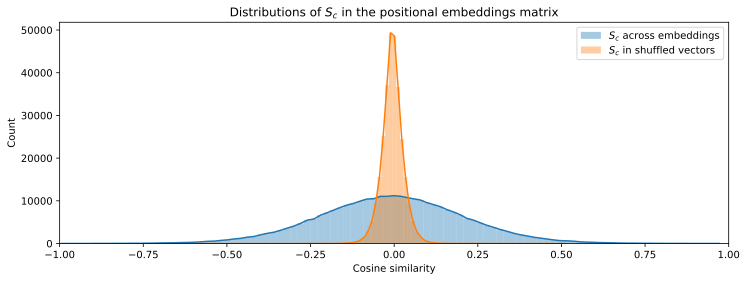

In [ ]:
# get the unique cosine similarity values from the upper-triangle
unique_cs_random = cossim_random[np.nonzero(np.triu(cossim_random,1))]

# get their distribution
random_hy,random_hx = np.histogram(unique_cs_random,100)

# visualize!
plt.figure(figsize=(12,4))D
plt.bar(embed_hx[:-1],embed_hy,width=np.diff(embed_hx[:2]),alpha=.4,label='$S_c$ across embeddings')
plt.bar(random_hx[:-1],random_hy,width=np.diff(random_hx[:2]),alpha=.4,label='$S_c$ in shuffled vectors')
plt.plot(embed_hx[:-1],embed_hy)
plt.plot(random_hx[:-1],random_hy)

plt.legend()
plt.gca().set(xlim=[-1,1],xlabel='Cosine similarity',ylabel='Count',title='Distributions of $S_c$ in the positional embeddings matrix')
plt.show()

# Exercise 3: Find similar pairs

Cossim of 0.992 in pair (356,528)
Cossim of 0.943 in pair (320,540)
Cossim of 0.915 in pair (308,528)
Cossim of 0.885 in pair (107,271)
Cossim of 0.864 in pair (365,525)
Cossim of 0.845 in pair (479,623)
Cossim of 0.829 in pair (49,724)
Cossim of 0.813 in pair (71,365)
Cossim of 0.800 in pair (167,439)
Cossim of 0.794 in pair (527,623)


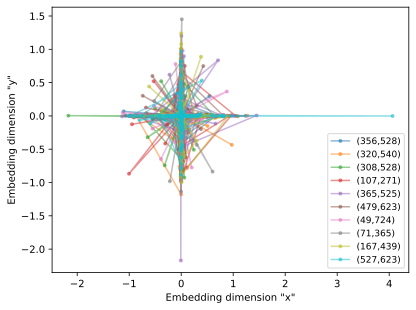

In [24]:
# reminder: positions matrix is size [index,embedding]


sortidx = np.argsort(np.triu(cossim_embeds,1).flatten())[::-1]
xx,yy = np.unravel_index(sortidx,cossim_embeds.shape)

for i in np.linspace(0,200,10).astype(int):

  # get and print the pairs
  pairname = f'({xx[i]},{yy[i]})'
  print(f'Cossim of {cossim_embeds[xx[i],yy[i]]:.3f} in pair {pairname}')

  # plot them
  plt.plot(positions[:,xx[i]],positions[:,yy[i]],'.-',alpha=.5,label=pairname)

# adjustments
plt.gca().set(xlabel='Embedding dimension "x"',ylabel='Embedding dimension "y"')
plt.legend(fontsize=9)
plt.show()